# M5: SMILES Transformer Baseline

Goal: represent SMILES as a sequence, train a small Transformer encoder, and compare it with the Morgan (M2/M3) and graph (M4) baselines on the **same Murcko scaffold split**.

The canonical reproduction entry is `src/models/smiles_transformer.py` (about 10 minutes of CPU training). This notebook can retrain it with `M5_RETRAIN=1`; by default it loads the saved JSON and verifies the split/tokenizer/model metadata.


In [1]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import json
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.style.use("seaborn-v0_8-whitegrid")

sys.path.insert(0, str(PROJECT_ROOT / "src" / "models"))
from evaluate_splits import scaffold_split_indices
from smiles_transformer import (
    SMILESTransformerRegressor,
    build_vocab,
    tokenize_smiles,
)

## 1. Same data and same scaffold split as M3/M4


In [2]:
final_df = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "egfr_activity_final.csv")
print(f"molecules: {len(final_df):,}")

smiles_list = final_df["canonical_smiles"].tolist()
y = final_df["pIC50"].to_numpy(dtype=np.float32)
train_idx, test_idx, scaffold_stats = scaffold_split_indices(smiles_list, test_size=0.2)
print(f"train={len(train_idx):,}  test={len(test_idx):,}")
print(f"scaffolds: {scaffold_stats['n_scaffolds']:,} "
      f"(train {scaffold_stats['scaffolds_train']:,}, "
      f"test {scaffold_stats['scaffolds_test']:,})")

molecules: 10,161
train=8,128  test=2,033
scaffolds: 3,641 (train 1,608, test 2,033)


## 2. SMILES tokenizer

SMILES are tokenized into atom-level tokens (`Cl`, `Br`, `[nH]`, punctuation, digits). The vocabulary is built from the training SMILES only.


In [3]:
train_smiles = [smiles_list[i] for i in train_idx]
vocab = build_vocab(train_smiles)
lengths = [len(tokenize_smiles(s)) for s in smiles_list]
print("example:", tokenize_smiles("Brc1cc2c(NCc3ccccc3)ncnc2s1"))
print(f"vocab size: {len(vocab):,}")
print(f"token length: mean={np.mean(lengths):.1f}, max={max(lengths)}")

example: ['Br', 'c', '1', 'c', 'c', '2', 'c', '(', 'N', 'C', 'c', '3', 'c', 'c', 'c', 'c', 'c', '3', ')', 'n', 'c', 'n', 'c', '2', 's', '1']
vocab size: 47
token length: mean=56.5, max=179


## 3. Transformer model (shown without retraining)

The model is a small Transformer encoder: token + position embeddings, 2 encoder layers, mean pooling over non-padding tokens, then a linear head to pIC50.


In [4]:
model = SMILESTransformerRegressor(
    vocab_size=len(vocab),
    max_len=max(lengths),
    d_model=64,
    nhead=4,
    num_layers=2,
    dim_feedforward=256,
    dropout=0.1,
)
n_params = sum(p.numel() for p in model.parameters())
print(f"Transformer parameters: {n_params:,}")

Transformer parameters: 118,657


## 4. Reproduction

The script `src/models/smiles_transformer.py` is the canonical training entry. To actually retrain from this notebook, set `M5_RETRAIN=1`; otherwise the saved JSON is used so the notebook stays fast.


In [5]:
if os.environ.get("M5_RETRAIN") == "1":
    subprocess.run(
        [sys.executable, str(PROJECT_ROOT / "src" / "models" / "smiles_transformer.py")],
        cwd=PROJECT_ROOT,
        check=True,
    )
    print("M5 retrained by src/models/smiles_transformer.py")
else:
    print("M5_RETRAIN=1 not set; using saved JSON (script is the reproduction entry).")

M5_RETRAIN=1 not set; using saved JSON (script is the reproduction entry).


## 5. Verify saved JSON metadata

Recompute the split, vocabulary, max length, and parameter count, then compare with the saved JSON.


In [6]:
m5_path = RESULTS_DIR / "m5_smiles_transformer_results.json"
m5 = json.loads(m5_path.read_text())
saved_split = m5["splits"]["scaffold"]

train_idx_again, test_idx_again, stats_again = scaffold_split_indices(
    smiles_list, test_size=0.2
)
checks = {
    "train_indices": saved_split["train_indices"] == train_idx_again,
    "test_indices": saved_split["test_indices"] == test_idx_again,
    "vocab_size": m5["tokenizer"]["vocab_size"] == len(vocab),
    "max_len": m5["tokenizer"]["max_len"] == max(lengths),
    "n_parameters": m5["model_params"]["n_parameters"] == n_params,
}
print(checks)
assert all(checks.values()), "M5 JSON metadata does not match recomputed values"
print("saved JSON metadata verified")

{'train_indices': True, 'test_indices': True, 'vocab_size': True, 'max_len': True, 'n_parameters': True}
saved JSON metadata verified


## 6. Saved M5 results


In [7]:
metrics = m5["splits"]["scaffold"]["metrics"]
print("SMILES Transformer scaffold-split metrics:")
for key, value in metrics.items():
    print(f"  {key}: {value:.4f}")

SMILES Transformer scaffold-split metrics:
  MAE: 0.9871
  RMSE: 1.2581
  R2: 0.0438
  Pearson_r: 0.4767
  Spearman_rho: 0.4686


## 7. Compare with M3 Morgan and M4 graph baselines


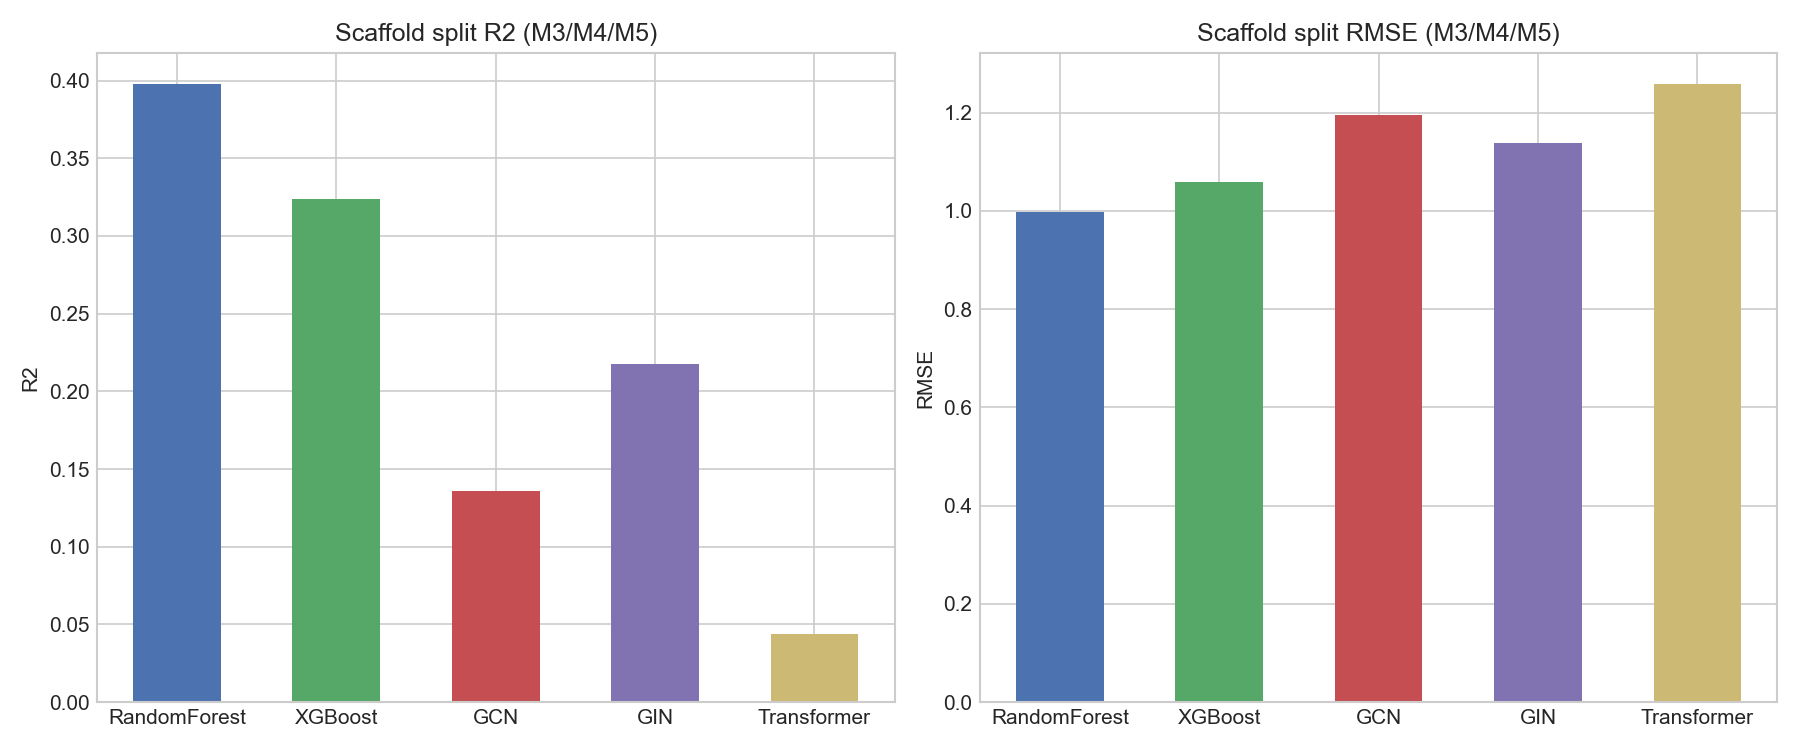

In [8]:
m3 = json.loads((RESULTS_DIR / "m3_morgan_split_comparison_results.json").read_text())["splits"]["scaffold"]["metrics"]
m4 = json.loads((RESULTS_DIR / "m4_graph_baseline_results.json").read_text())["splits"]["scaffold"]["metrics"]

model_names = ["RandomForest", "XGBoost", "GCN", "GIN", "Transformer"]
r2_values = [
    m3["RandomForest"]["R2"],
    m3["XGBoost"]["R2"],
    m4["GCN"]["R2"],
    m4["GIN"]["R2"],
    metrics["R2"],
]
rmse_values = [
    m3["RandomForest"]["RMSE"],
    m3["XGBoost"]["RMSE"],
    m4["GCN"]["RMSE"],
    m4["GIN"]["RMSE"],
    metrics["RMSE"],
]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
x = np.arange(len(model_names))
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2", "#CCB974"]
axes[0].bar(x, r2_values, 0.55, color=colors)
axes[0].set_xticks(x); axes[0].set_xticklabels(model_names)
axes[0].set_ylabel("R2"); axes[0].set_title("Scaffold split R2 (M3/M4/M5)")
axes[1].bar(x, rmse_values, 0.55, color=colors)
axes[1].set_xticks(x); axes[1].set_xticklabels(model_names)
axes[1].set_ylabel("RMSE"); axes[1].set_title("Scaffold split RMSE (M3/M4/M5)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "m5_smiles_transformer_scaffold_comparison.png", dpi=150)
plt.show()

## 8. How to interpret the results

1. The SMILES Transformer has the worst scaffold-split performance of all five baselines (R2 = 0.044).
2. R2 is low while Pearson is moderate, which is typical of predictions compressed toward the mean.
3. The split is the same extreme "new scaffold" split as M3/M4: all test scaffolds are singletons, and the test pIC50 distribution is shifted lower.
4. This is a useful negative result: a small, lightly-tuned learned sequence representation does not beat simple fingerprints on unseen scaffolds.
